**RFM Analysis using K-means Clustering**

**1.import the library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import plotly.offline as pyoff
import plotly.graph_objs as go
!pip install feature-engine
import datetime as dt
import feature_engine

from feature_engine.outliers import Winsorizer

import warnings
warnings.filterwarnings("ignore")

: 

**Read the file**

In [4]:
df = pd.read_csv('OnlineRetail.csv',encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
75101,542541,22124,SET OF 2 TEA TOWELS PING MICROWAVE,1.0,1/28/2011 14:25,2.46,NaN,United Kingdom
75102,542541,22131,FOOD CONTAINER SET 3 LOVE HEART,1.0,1/28/2011 14:25,4.13,NaN,United Kingdom
75103,542541,22135,MINI LADLE LOVE HEART PINK,1.0,1/28/2011 14:25,0.83,NaN,United Kingdom
75104,542541,22148,EASTER CRAFT 4 CHICKS,3.0,1/28/2011 14:25,4.13,NaN,United Kingdom
75105,542541,22149,FELTCRAFT 6 FLOWER FRIENDS,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(75106, 8)

**2.Data Preparation**

In [7]:
def summary(df, pred=None):
  obs = df.shape[0]
  types = df.dtypes
  counts = df.apply(lambda x: x.count())
  min = df.select_dtypes(include=np.number).min()
  uniques = df.apply(lambda x: x.unique().shape[0])
  nulls = df.apply(lambda x: x.isnull().sum())
  print('Data shape:', df.shape)

  if pred is None:
        cols = ['types', 'counts', 'uniques', 'nulls', 'min']
        str = pd.concat([types, counts, uniques, nulls, min], axis = 1, sort=True)

  str.columns = cols
  dtypes = str.types.value_counts()
  print('___________________________\nData types:')
  print(str.types.value_counts())
  print('___________________________')
  return str
details = summary(df)
display(details.sort_values(by='nulls', ascending=False))

Data shape: (75106, 8)
___________________________
Data types:
types
object     5
float64    3
Name: count, dtype: int64
___________________________


,types,counts,uniques,nulls,min
CustomerID,float64,46828,1341,28278,12346.0
Description,object,74903,2949,203,NaN
Country,object,75105,29,1,NaN
InvoiceDate,object,75105,2991,1,NaN
Quantity,float64,75105,257,1,-74215.0
UnitPrice,float64,75105,461,1,0.0
InvoiceNo,object,75106,3339,0,NaN
StockCode,object,75106,3019,0,NaN


In [8]:
df.describe()


,Quantity,UnitPrice,CustomerID
count,75105.000000,75105.000000,46828.000000
mean,8.438147,5.639838,15347.426283
std,387.156865,136.348094,1762.929568
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13959.000000
50%,2.000000,2.510000,15311.000000
75%,8.000000,4.210000,16931.000000
max,74215.000000,16888.020000,18283.000000


In [9]:
df.loc[(df.UnitPrice<0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [10]:
df.loc[(df.Quantity<0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1.0,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1.0,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12.0,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24.0,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24.0,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
75001,C542539,22567,20 DOLLY PEGS RETROSPOT,-12.0,1/28/2011 14:07,1.25,14229.0,United Kingdom
75002,C542539,22423,REGENCY CAKESTAND 3 TIER,-7.0,1/28/2011 14:07,10.95,14229.0,United Kingdom
75003,C542540,POST,POSTAGE,-1.0,1/28/2011 14:20,4.41,NaN,United Kingdom
75004,C542540,DOT,DOTCOM POSTAGE,-1.0,1/28/2011 14:20,3.29,NaN,United Kingdom


In [11]:
df.isnull().mean()*100

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.270285
Quantity,0.001331
InvoiceDate,0.001331
UnitPrice,0.001331
CustomerID,37.650787
Country,0.001331


In [12]:
df.Country.value_counts(normalize=True)

,proportion
Country,
United Kingdom,0.928740
Germany,0.016910
France,0.013967
EIRE,0.007882
Spain,0.006125
Netherlands,0.003888
Portugal,0.003222
Switzerland,0.002330
Belgium,0.002104


In [13]:
df = df[df.Country == 'United Kingdom']

**Removing the negative values from UnitPrice and Quantity**

In [14]:
df = df[df.Quantity > 0]
df = df[df.UnitPrice > 0]

#Removing the Null values from the data.
df = df[pd.notnull(df['CustomerID'])]

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceYearMonth'] = df['InvoiceDate'].map(lambda date: 100*date.year + date.month)
df['Date'] = df['InvoiceDate'].dt.strftime('%Y-%m')

In [16]:
df.isnull().mean()

,0
InvoiceNo,0.0
StockCode,0.0
Description,0.0
Quantity,0.0
InvoiceDate,0.0
UnitPrice,0.0
CustomerID,0.0
Country,0.0
InvoiceYearMonth,0.0
Date,0.0


**Aggregating the Orders by Month**

In [17]:
df_agg= df.groupby("Date").Quantity.sum()
df_agg

,Quantity
Date,
2010-12,267767.0
2011-01,264445.0


In [18]:
#converting series to dataframe and resetting index, and changing the column name to 'Orders'
df_agg=pd.DataFrame(df_agg)
df_agg=df_agg.reset_index()
df_agg.head()

,Date,Quantity
0,2010-12,267767.0
1,2011-01,264445.0


In [19]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Orders', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.plot(x, y, color='tab:Blue', marker='o')
    plt.show()

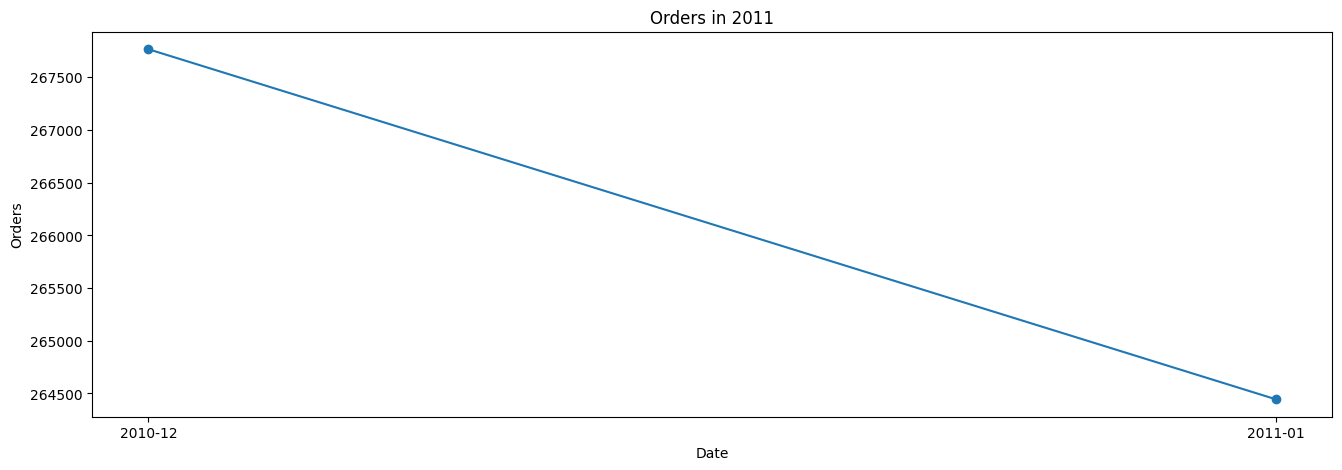

In [60]:
plot_df(df_agg, x=df_agg.Date, y=df_agg.Quantity,title='Orders in 2011')

**Calculating Revenue**
Revenue = Order Count * Average Revenue per Order

In [21]:
df['Revenue'] = df['Quantity']*df['UnitPrice']

<Axes: xlabel='Quantity'>

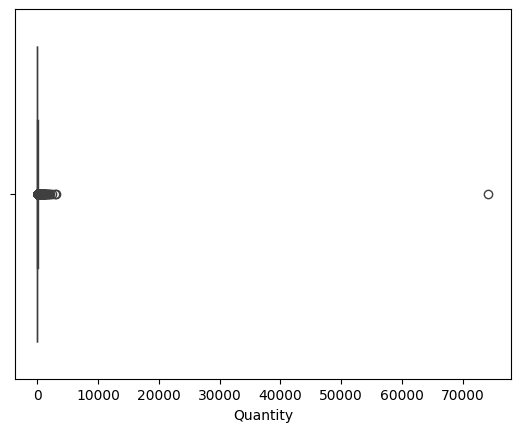

In [22]:
sns.boxplot(x=df['Quantity'])

In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceYearMonth,Date,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,201012,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,201012,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,201012,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,201012,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,201012,2010-12,20.34


**Monthly Revenue**

In [24]:
df_revenue = df.groupby(['InvoiceYearMonth'])['Revenue'].sum().reset_index()
df_revenue.tail()

,InvoiceYearMonth,Revenue
0,201012,498661.85
1,201101,420371.49


In [25]:
plot_data = [
    go.Scatter(
        x=df_revenue['InvoiceYearMonth'],
        y=df_revenue['Revenue'],
        mode='lines+markers'
    )
]

plot_layout = go.Layout(
        xaxis={"type": "category"},
        title='Montly Revenue'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)


**RFM Analysis**

**Recency-Frequency-Monetary**

In [26]:
NOW = dt.date(2011,12,9)
df['Date'] = pd.DatetimeIndex(df.InvoiceDate).date

**Recency**

In [27]:
df_recency = df.groupby(['CustomerID'],as_index=False)['Date'].max()
df_recency.columns = ['CustomerID','Last_Purchase_Date']

df_recency['Recency'] = df_recency.Last_Purchase_Date.apply(lambda x:(NOW - x).days)
df_recency.drop(columns=['Last_Purchase_Date'],inplace=True)
df_recency.head()

,CustomerID,Recency
0,12346.0,325
1,12747.0,323
2,12748.0,325
3,12820.0,326
4,12826.0,316


**Frequency - Monetarty**

In [28]:
FM_Table = df.groupby('CustomerID').agg({'InvoiceNo'   : lambda x:len(x),
                                         'Revenue'  : lambda x:x.sum()})
FM_Table.rename(columns = {'InvoiceNo' :'Frequency',
                           'Revenue':'Monetary'},inplace= True)
FM_Table.head()

,Frequency,Monetary
CustomerID,,
12346.0,1,77183.60
12747.0,20,1009.31
12748.0,693,4646.90
12820.0,11,170.46
12826.0,49,697.10


**Calculating the total RFM score combined**

RFM_Score = R_quartile + F_quartile + M_quartile

In [29]:
RFM_Table = df_recency.merge(FM_Table,left_on='CustomerID',right_on='CustomerID')
RFM_Table.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12747.0,323,20,1009.31
2,12748.0,325,693,4646.90
3,12820.0,326,11,170.46
4,12826.0,316,49,697.10


In [30]:
(NOW - dt.date(2011,1,18)).days == 325

True

In [31]:
quantiles = RFM_Table.quantile(q=[0.25,0.50,0.75])
quantiles = quantiles.to_dict()

In [32]:
segmented_rfm = RFM_Table.copy()

In [33]:
def RScore(x,p,d):
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]:
        return 3
    else:
        return 4

def FMScore(x,p,d):
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]:
        return 2
    else:
        return 1

In [34]:
segmented_rfm['R_quartile'] = segmented_rfm['Recency'].apply(RScore, args=('Recency',quantiles))
segmented_rfm['F_quartile'] = segmented_rfm['Frequency'].apply(FMScore, args=('Frequency',quantiles))
segmented_rfm['M_quartile'] = segmented_rfm['Monetary'].apply(FMScore, args=('Monetary',quantiles))
segmented_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_quartile,F_quartile,M_quartile
0,12346.0,325,1,77183.60,1,4,1
1,12747.0,323,20,1009.31,1,3,1
2,12748.0,325,693,4646.90,1,1,1
3,12820.0,326,11,170.46,2,3,4
4,12826.0,316,49,697.10,1,1,1


In [35]:
segmented_rfm['RFM_Segment'] = segmented_rfm.R_quartile.map(str)+segmented_rfm.F_quartile.map(str)+segmented_rfm.M_quartile.map(str)

In [36]:
segmented_rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_quartile,F_quartile,M_quartile,RFM_Segment
0,12346.0,325,1,77183.60,1,4,1,141
1,12747.0,323,20,1009.31,1,3,1,131
2,12748.0,325,693,4646.90,1,1,1,111
3,12820.0,326,11,170.46,2,3,4,234
4,12826.0,316,49,697.10,1,1,1,111


In [37]:
segmented_rfm['RFM_Score'] = segmented_rfm[['R_quartile','F_quartile','M_quartile']].sum(axis=1)

In [38]:
segmented_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_quartile,F_quartile,M_quartile,RFM_Segment,RFM_Score
0,12346.0,325,1,77183.60,1,4,1,141,6
1,12747.0,323,20,1009.31,1,3,1,131,5
2,12748.0,325,693,4646.90,1,1,1,111,3
3,12820.0,326,11,170.46,2,3,4,234,9
4,12826.0,316,49,697.10,1,1,1,111,3


In [39]:
print("Best Customers: ",len(segmented_rfm[segmented_rfm['RFM_Segment']=='111']))
print('Loyal Customers: ',len(segmented_rfm[segmented_rfm['F_quartile']==1]))
print("Big Spenders: ",len(segmented_rfm[segmented_rfm['M_quartile']==1]))
print('Almost Lost: ', len(segmented_rfm[segmented_rfm['RFM_Segment']=='134']))
print('Lost Customers: ',len(segmented_rfm[segmented_rfm['RFM_Segment']=='344']))
print('Lost Cheap Customers: ',len(segmented_rfm[segmented_rfm['RFM_Segment']=='444']))

Best Customers:  81
Loyal Customers:  284
Big Spenders:  286
Almost Lost:  9
Lost Customers:  41
Lost Cheap Customers:  60


In [42]:
segmented_rfm['RFM_Score'].unique()

array([ 6,  5,  3,  9,  8,  7, 12,  4, 10, 11])

In [43]:
segmented_rfm.groupby('RFM_Score').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count'] }).round(1)

Recency Frequency Monetary      
             mean      mean     mean count
RFM_Score                                 
3           319.2     119.4   2395.6    81
4           325.3      73.2   1735.5   100
5           332.7      50.5    957.9   109
6           337.0      40.2   1501.0   110
7           342.5      30.1    678.1   156
8           347.6      25.3    534.0   151
9           348.7      14.7    281.9   161
10          355.8      12.9    217.1   129
11          364.0       7.6    175.1    87
12          369.0       5.0    114.7    60

**K-means to perform RFM (Recency, Frequency, and Monetary) customer segmentation.**

In [44]:
## Function to check skewness
def check_skew(df_skew, column):
    skew = stats.skew(df_skew[column])
    skewtest = stats.skewtest(df_skew[column])
    plt.title('Distribution of ' + column)
    sns.distplot(df_skew[column])
    print("{}'s: Skew: {}, : {}".format(column, skew, skewtest))
    return

Recency's: Skew: 0.009349674651252615, : SkewtestResult(statistic=0.12993284018919485, pvalue=0.8966195618068343)
Frequency's: Skew: 5.676661980079825, : SkewtestResult(statistic=30.109573765294087, pvalue=3.6309081257707357e-199)
Monetary's: Skew: 18.918954327411104, : SkewtestResult(statistic=43.84878008862027, pvalue=0.0)


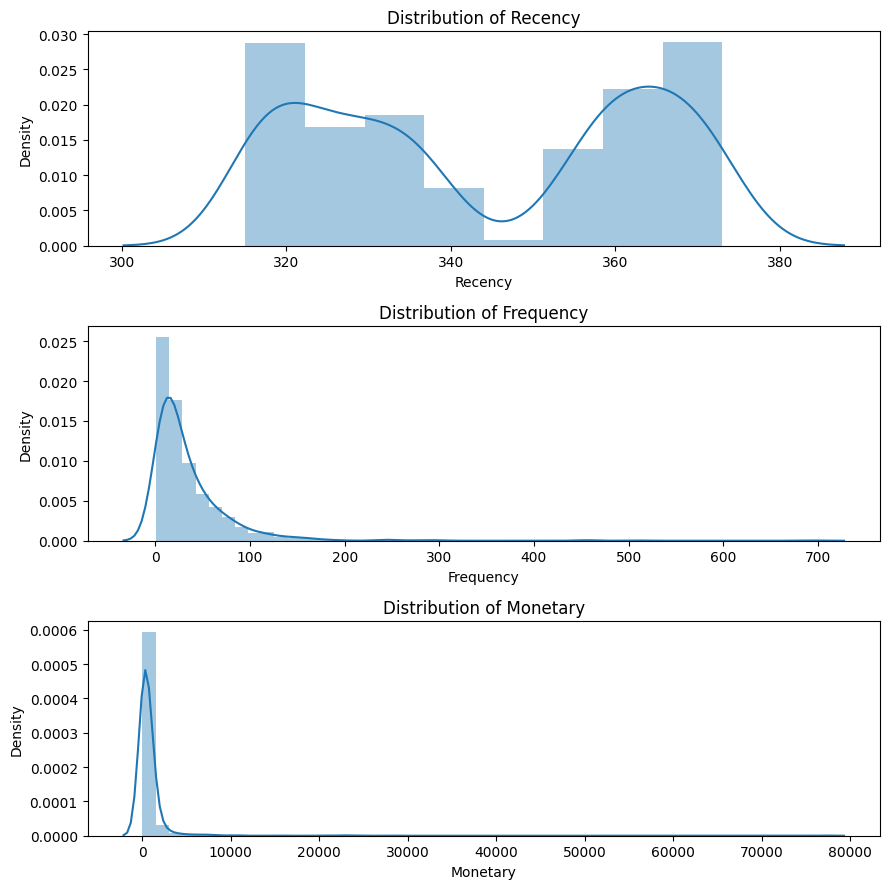

In [45]:
# Plot all 3 graphs together for summary findings
plt.figure(figsize=(9, 9))

plt.subplot(3, 1, 1)
check_skew(RFM_Table,'Recency')

plt.subplot(3, 1, 2)
check_skew(RFM_Table,'Frequency')

plt.subplot(3, 1, 3)
check_skew(RFM_Table,'Monetary')

plt.tight_layout()

In [46]:
df_rfm_log = RFM_Table.copy()
df_rfm_log.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12747.0,323,20,1009.31
2,12748.0,325,693,4646.90
3,12820.0,326,11,170.46
4,12826.0,316,49,697.10


Recency's: Skew: -0.025059612593486196, : SkewtestResult(statistic=-0.3482084066113709, pvalue=0.7276836748237887)
Frequency's: Skew: -0.16255549503724231, : SkewtestResult(statistic=-2.244704428550173, pvalue=0.024787113565112057)
Monetary's: Skew: 0.5010120780025482, : SkewtestResult(statistic=6.59289947615778, pvalue=4.3131863727058225e-11)


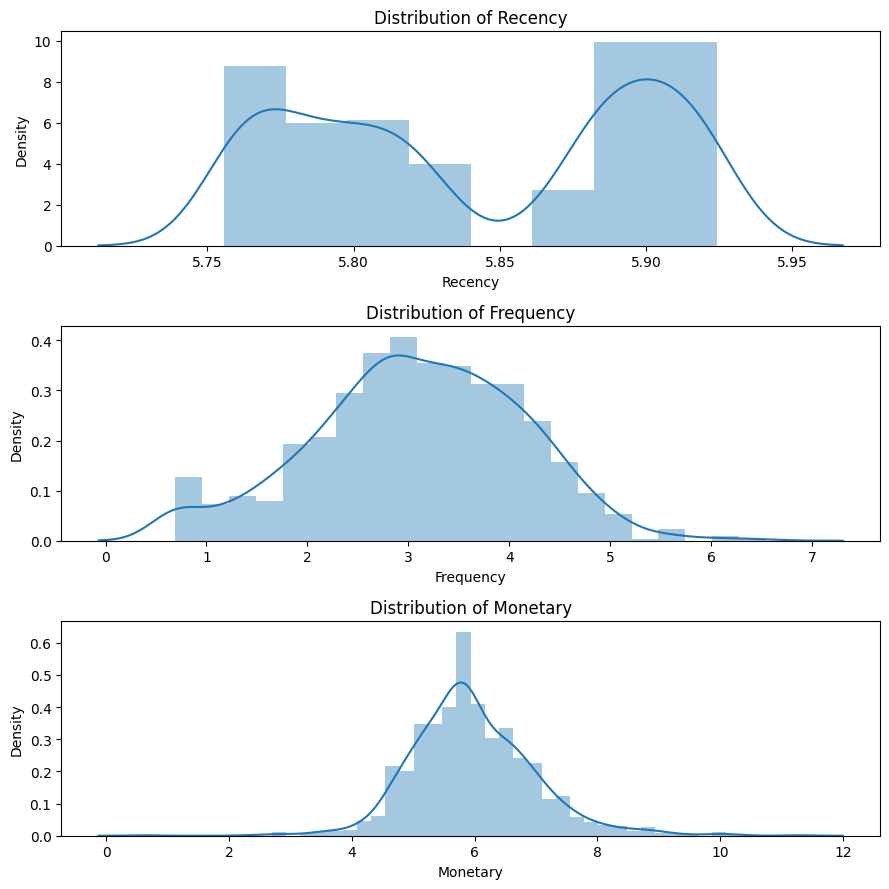

In [47]:
df_rfm_log = np.log(df_rfm_log+1)

plt.figure(figsize=(9, 9))

plt.subplot(3, 1, 1)
check_skew(df_rfm_log,'Recency')

plt.subplot(3, 1, 2)
check_skew(df_rfm_log,'Frequency')
plt.subplot(3, 1, 3)
check_skew(df_rfm_log,'Monetary')

plt.tight_layout()

In [48]:
RFM_Table.describe()

,CustomerID,Recency,Frequency,Monetary
count,1144.000000,1144.000000,1144.000000,1144.000000
mean,15600.294580,343.971154,35.369755,803.350822
std,1593.194947,20.191430,47.152649,2855.100029
min,12346.000000,315.000000,1.000000,0.850000
25%,14246.750000,325.000000,10.000000,204.577500
50%,15606.500000,338.000000,21.000000,349.105000
75%,16983.500000,364.000000,45.000000,693.205000
max,18283.000000,373.000000,693.000000,77183.600000


In [49]:
windsoriser = Winsorizer(tail='both', # cap left, right or both tails
                          fold=2,
                           variables=[ 'Recency', 'Frequency', 'Monetary']
                        )
windsoriser.fit(df_rfm_log)

Winsorizer(fold=2, tail='both', variables=['Recency', 'Frequency', 'Monetary'])

In [50]:
df_rfm_log = windsoriser.transform(df_rfm_log)

In [51]:
scaler = StandardScaler()

scaler.fit(df_rfm_log)

RFM_Table_scaled = scaler.transform(df_rfm_log)
RFM_Table_scaled = pd.DataFrame(RFM_Table_scaled, columns=df_rfm_log.columns)
RFM_Table_scaled.head()

,CustomerID,Recency,Frequency,Monetary
0,-2.216391,-0.936108,-2.081984,2.259070
1,-1.906590,-1.041137,-0.041355,1.074257
2,-1.905830,-0.936108,2.073911,2.259070
3,-1.851243,-0.883835,-0.600585,-0.892090
4,-1.846707,-1.413914,0.825548,0.664449


**K-Means Clustering**

Finding the optimal number of clusters

In [52]:
from scipy.spatial.distance import cdist
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1,10)

for k in K:
    #Building and fitting the model
    kmeanModel = KMeans(n_clusters=k).fit(RFM_Table_scaled)
    kmeanModel.fit(RFM_Table_scaled)

    distortions.append(sum(np.min(cdist(RFM_Table_scaled, kmeanModel.cluster_centers_,
                      'euclidean'),axis=1)) / RFM_Table_scaled.shape[0])
    inertias.append(kmeanModel.inertia_)

    mapping1[k] = sum(np.min(cdist(RFM_Table_scaled, kmeanModel.cluster_centers_,
                 'euclidean'),axis=1)) / RFM_Table_scaled.shape[0]
    mapping2[k] = kmeanModel.inertia_

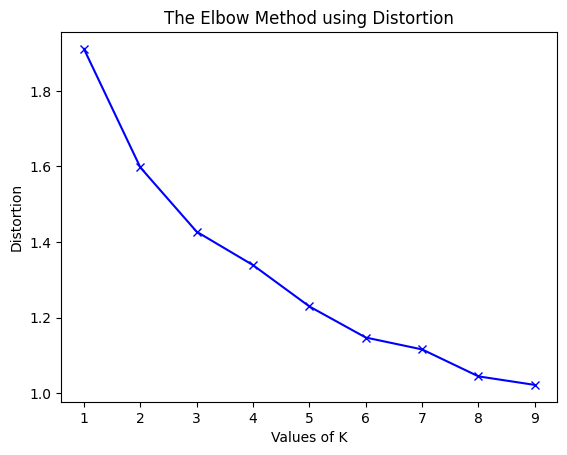

In [53]:
plt.plot(K, distortions, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

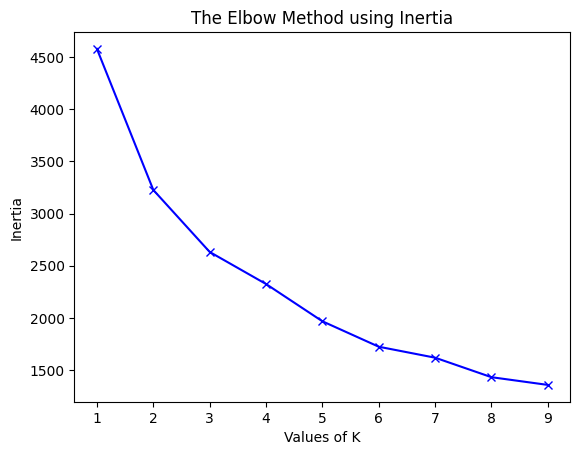

In [54]:
plt.plot(K, inertias, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

In [55]:
def kmeans(normalised_df_rfm, clusters_number, original_df_rfm):

    kmeans = KMeans(n_clusters = clusters_number, random_state = 1)
    kmeans.fit(normalised_df_rfm)

    # Extract cluster labels
    cluster_labels = kmeans.labels_

    # Create a cluster label column in original dataset
    df_new = original_df_rfm.assign(Cluster = cluster_labels)

    # Initialise TSNE
    model = TSNE(random_state=1)
    transformed = model.fit_transform(df_new)

    # Plot t-SNE
    plt.title('Flattened Graph of {} Clusters'.format(clusters_number))
    sns.scatterplot(x=transformed[:,0], y=transformed[:,1], hue=cluster_labels, style=cluster_labels, palette="Set1")

    return df_new

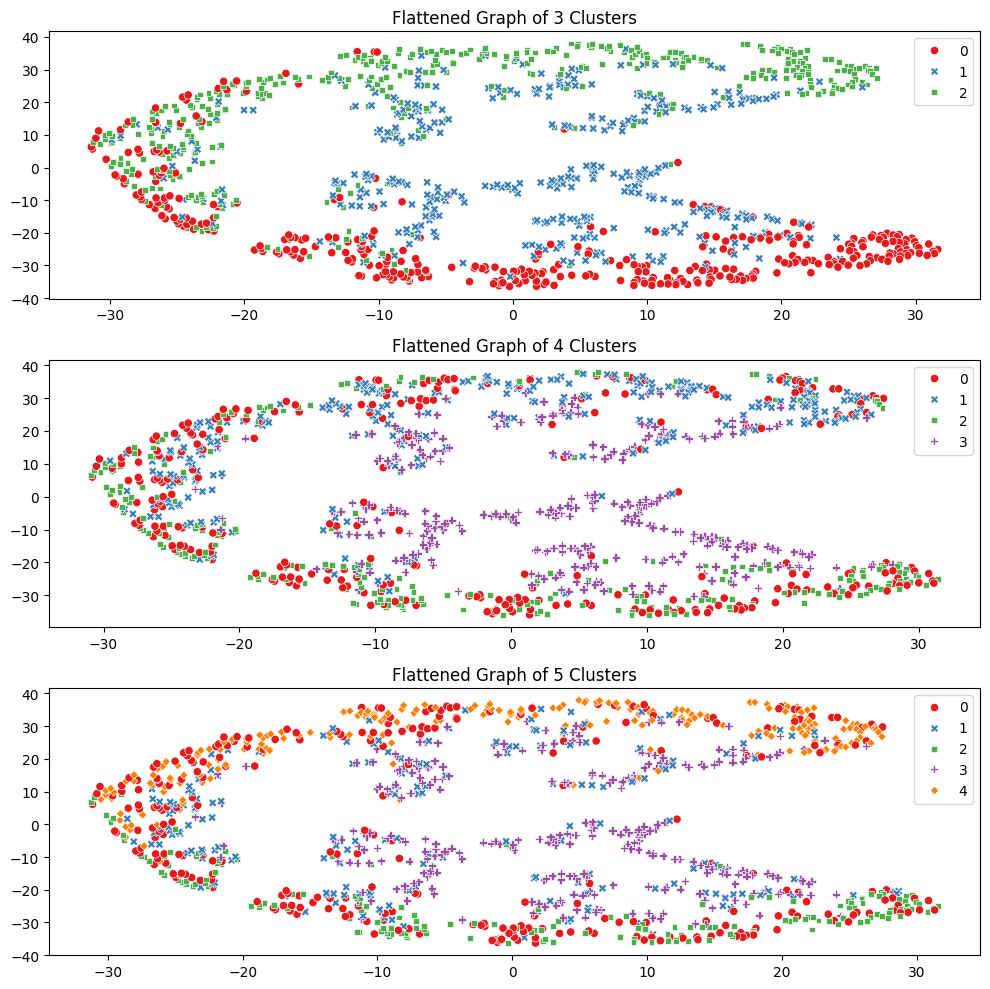

In [56]:
plt.figure(figsize=(10, 10))

plt.subplot(3, 1, 1)
df_rfm_k3 = kmeans(RFM_Table_scaled, 3, RFM_Table)

plt.subplot(3, 1, 2)
df_rfm_k4 = kmeans(RFM_Table_scaled, 4, RFM_Table)

plt.subplot(3, 1, 3)
df_rfm_k5 = kmeans(RFM_Table_scaled, 5, RFM_Table)

plt.tight_layout()

In [57]:
def snake_plot(normalised_df_rfm, df_rfm_kmeans, df_rfm_original):

    normalised_df_rfm = pd.DataFrame(normalised_df_rfm,
                                       index=RFM_Table.index,
                                       columns=RFM_Table.columns)
    normalised_df_rfm['Cluster'] = df_rfm_kmeans['Cluster']

    # Melt data into long format
    df_melt = pd.melt(normalised_df_rfm.reset_index(),
                        id_vars=['CustomerID', 'Cluster'],
                        value_vars=['Recency', 'Frequency', 'Monetary'],
                        var_name='Metric',
                        value_name='Value')

    plt.xlabel('Metric')
    plt.ylabel('Value')
    sns.pointplot(data=df_melt, x='Metric', y='Value', hue='Cluster')

    return

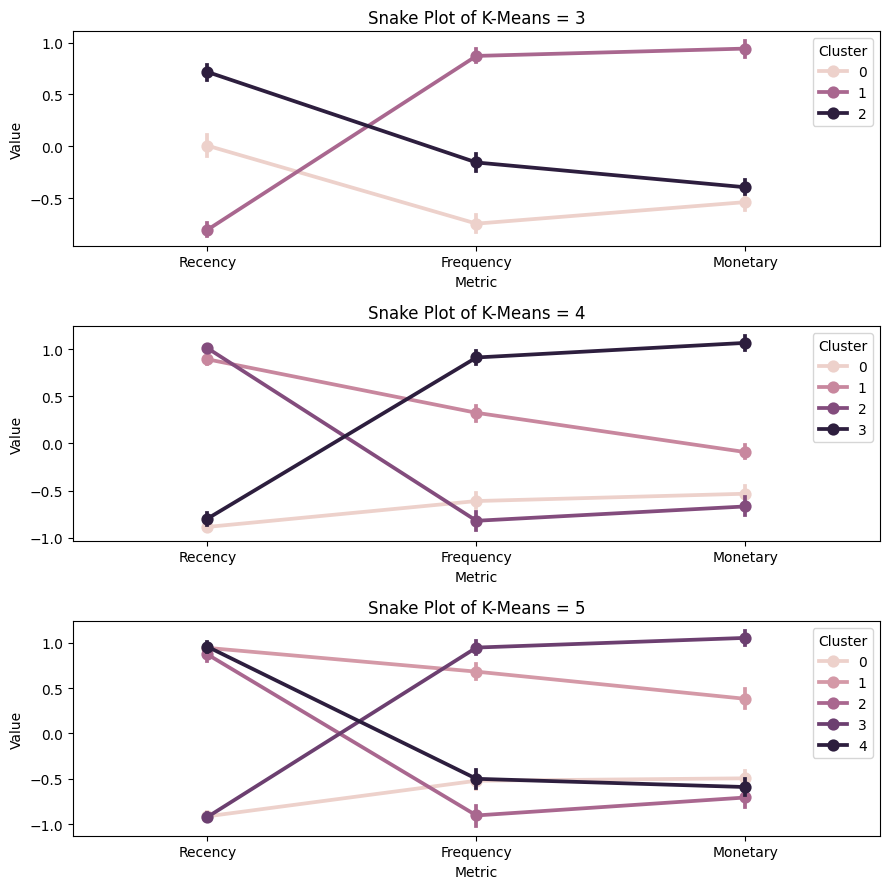

In [58]:
plt.figure(figsize=(9, 9))

plt.subplot(3, 1, 1)
plt.title('Snake Plot of K-Means = 3')
snake_plot(RFM_Table_scaled, df_rfm_k3, RFM_Table)

plt.subplot(3, 1, 2)
plt.title('Snake Plot of K-Means = 4')
snake_plot(RFM_Table_scaled, df_rfm_k4, RFM_Table)

plt.subplot(3, 1, 3)
plt.title('Snake Plot of K-Means = 5')
snake_plot(RFM_Table_scaled, df_rfm_k5, RFM_Table)

plt.tight_layout()

**Interpretation of the clusters formed using k-means .**

In [59]:
def rfm_values(df):

    df_new = df.groupby(['Cluster']).agg({
        'Recency': 'mean',
        'Frequency': 'mean',
        'Monetary': ['mean', 'count']
    }).round(0)

    return df_new
rfm_values(df_rfm_k4)

Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         326.0      14.0    565.0   279
1         362.0      38.0    529.0   271
2         364.0      12.0    269.0   265
3         328.0      71.0   1661.0   329